Use the best individual model (XGBoost recommended for ablation).

In [2]:
import pandas as pd
import numpy as np

# Load dataset again
df = pd.read_csv("../data/crop_recommendation.csv")

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y = le.fit_transform(df["label"])
X = df.drop("label", axis=1)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Baseline model
baseline_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="mlogloss"
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_acc)


Baseline Accuracy: 0.9886363636363636


In [6]:
feature_results = []

for feature in X.columns:
    
    # Drop one feature
    X_train_drop = X_train.drop(columns=[feature])
    X_test_drop = X_test.drop(columns=[feature])
    
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y)),
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric="mlogloss"
    )
    
    model.fit(X_train_drop, y_train)
    
    pred = model.predict(X_test_drop)
    acc = accuracy_score(y_test, pred)
    
    feature_results.append({
        "Removed Feature": feature,
        "Accuracy": acc,
        "Accuracy Drop": baseline_acc - acc
    })


Ablation Loop - Remove one feature at a time

In [7]:
import pandas as pd

ablation_df = pd.DataFrame(feature_results)

ablation_df = ablation_df.sort_values(
    by="Accuracy Drop",
    ascending=False
)

ablation_df


,Removed Feature,Accuracy,Accuracy Drop
6,rainfall,0.965909,0.022727
4,humidity,0.979545,0.009091
1,P,0.981818,0.006818
2,K,0.981818,0.006818
0,N,0.986364,0.002273
3,temperature,0.986364,0.002273
5,ph,0.986364,0.002273


Rainfall is the most critical feature. Humidity is important but secondary. P and K are moderatley important and help refine crop classification. N, temperature and pH are important but redundant or partially captured by other variables.

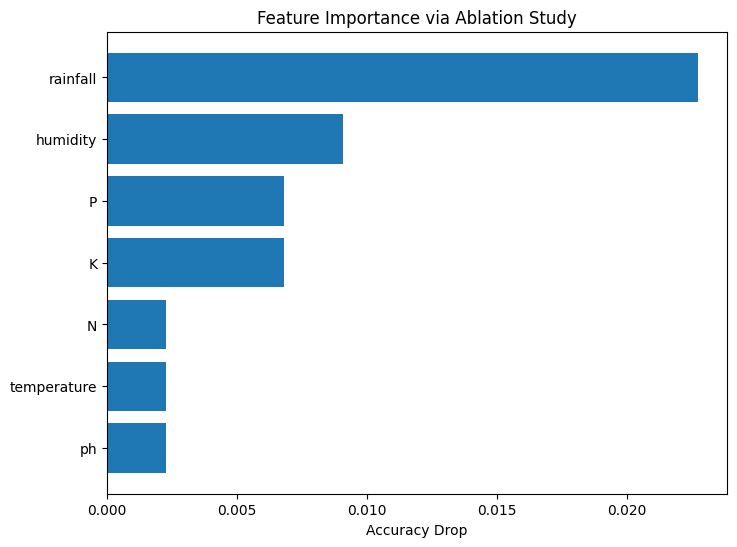

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(ablation_df["Removed Feature"], 
         ablation_df["Accuracy Drop"])
plt.xlabel("Accuracy Drop")
plt.title("Feature Importance via Ablation Study")
plt.gca().invert_yaxis()
plt.show()


We performed an ablation study by removing each feature individually and observing the change in model accuracy. Features causing the largest accuracy drop were considered most influential in crop prediction.



Now instaed of removing features individually, we remove logical groups like soil features - N,P,K,pH and climate features like temperature, humidity and rainfall. This answers which domain contributes more to crop prediction.

In [11]:
baseline_model.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline_model.predict(X_test))

print("Baseline Accuracy:", baseline_acc)


Baseline Accuracy: 0.9886363636363636


In [12]:
soil_features = ["N", "P", "K", "ph"]

X_train_no_soil = X_train.drop(columns=soil_features)
X_test_no_soil = X_test.drop(columns=soil_features)

model_no_soil = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="mlogloss"
)

model_no_soil.fit(X_train_no_soil, y_train)

soil_removed_acc = accuracy_score(
    y_test,
    model_no_soil.predict(X_test_no_soil)
)

print("Accuracy without Soil Features:", soil_removed_acc)
print("Accuracy Drop:", baseline_acc - soil_removed_acc)


Accuracy without Soil Features: 0.9181818181818182
Accuracy Drop: 0.07045454545454544


Remove soil features.

In [13]:
climate_features = ["temperature", "humidity", "rainfall"]

X_train_no_climate = X_train.drop(columns=climate_features)
X_test_no_climate = X_test.drop(columns=climate_features)

model_no_climate = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="mlogloss"
)

model_no_climate.fit(X_train_no_climate, y_train)

climate_removed_acc = accuracy_score(
    y_test,
    model_no_climate.predict(X_test_no_climate)
)

print("Accuracy without Climate Features:", climate_removed_acc)
print("Accuracy Drop:", baseline_acc - climate_removed_acc)


Accuracy without Climate Features: 0.7704545454545455
Accuracy Drop: 0.21818181818181814


Remove climate features.

In [14]:
grouped_results = pd.DataFrame({
    "Scenario": ["Baseline",
                 "Without Soil Features",
                 "Without Climate Features"],
    "Accuracy": [baseline_acc,
                 soil_removed_acc,
                 climate_removed_acc]
})

grouped_results["Accuracy Drop"] = baseline_acc - grouped_results["Accuracy"]

grouped_results


,Scenario,Accuracy,Accuracy Drop
0,Baseline,0.988636,0.000000
1,Without Soil Features,0.918182,0.070455
2,Without Climate Features,0.770455,0.218182


Grouped ablation reveals that climate features contribute more significantly than soil features in crop prediction, particularly rainfall. However, soil nutrients refine classification boundaries.